In [186]:
import importlib
import model_utils

importlib.reload(model_utils)


<module 'model_utils' from '/Users/ehabhasan/Documents/Projects/Time Series Forecasting/Large Scale Forecasting/EU Electricity Load Forecasting/model_utils.py'>

In [187]:
import pandas as pd
import model_utils
import numpy as np
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display


# Load data

In [188]:
train=pd.read_csv('Data/training.csv')
val=pd.read_csv('Data/valid.csv')
test=pd.read_csv('Data/testing.csv')
country_map=pd.read_csv('Data/country_map.csv')
country_map.columns=['Country','CountryCode']


# Hyperparameter Tuning

Based on benchmarking results, the CNN-LSTM model achieved the lowest MAE after seed-based tuning, outperforming WaveNet and other architectures. Therefore, I prioritized hyperparameter tuning and evaluation for CNN-LSTM. WaveNet remains a secondary candidate for future comparison or improvement if needed.

In [189]:
# Set up the data window and model builder with consistent seed list for reproducible tuning
seed_list = [22, 128, 777]
window = model_utils.DataWindow(
    input_width=24,
    label_width=24,
    shift=24,
    train_df=train,
    test_df=test,
    val_df=val,
    label_columns=['Value'],
    shuffle=True
)
builder = model_utils.ModelBuilder(window, train)

- Both CNN-LSTM and WaveNet achieved strong performance after seed-based tuning.
- CNN-LSTM achieved the lowest validation MAE and slightly better generalization on the test set.
- WaveNet remains a strong secondary candidate for further comparison or ensembling.

## Wavenet

In [190]:
best_model_wavenet, best_hp_wavenet, weights_path_wavenet = model_utils.tuning(
    seed_list=seed_list,
    builder=builder,
    model_input='wavenet',
    window=window
)

Trial 5 Complete [00h 00m 11s]
val_mae: 0.07515121251344681

Best val_mae So Far: 0.06520296633243561
Total elapsed time: 00h 01m 34s


/opt/anaconda3/envs/ML-env1/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 80 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



===== Best wavenet Result Across Seeds =====
Best Seed: 128
Best Validation MAE: 0.06330718100070953
Best Test MAE: 0.06919935345649719
Best Hyperparameters: {'filters': 16, 'kernel_size': 3, 'embedding_output_dim': 2, 'learning_rate': 0.0005}
Weights loaded from: tuning_est/wavenet_tuning_seed_128/trial_3/checkpoint.weights.h5


## CNN_LSTM

In [191]:
best_model_cnn_lstm, best_hp_cnn_lstm, weights_path_cnn_lstm = model_utils.tuning(
    seed_list=seed_list,
    builder=builder,
    model_input='cnn_lstm',
    window=window
)

Trial 5 Complete [00h 00m 26s]
val_mae: 0.06297587603330612

Best val_mae So Far: 0.0613880418241024
Total elapsed time: 00h 01m 37s


/opt/anaconda3/envs/ML-env1/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



===== Best cnn_lstm Result Across Seeds =====
Best Seed: 128
Best Validation MAE: 0.06045776233077049
Best Test MAE: 0.06688198447227478
Best Hyperparameters: {'filters': 64, 'kernel_size': 2, 'embedding_output_dim': 4, 'learning_rate': 0.001, 'lstm_units': 16}
Weights loaded from: tuning_est/cnn_lstm_tuning_seed_128/trial_2/checkpoint.weights.h5


# Model Evaluation

## Load Model

- Create a window for evaluation with shuffling disabled

In [192]:
window_eva = model_utils.DataWindow(
    input_width=24,
    label_width=24,
    shift=24,
    train_df=train,
    test_df=test,
    val_df=val,
    label_columns=['Value'],
    shuffle=False
)

- Rebuild and Load Best CNN-LSTM Model for Evaluation

In [194]:
builder_eva = model_utils.ModelBuilder(window_eva, train)
best_model_eva = builder.cnn_lstm(
    filters=best_hp_cnn_lstm.get('filters'),
    kernel_size=best_hp_cnn_lstm.get('kernel_size'),
    drop_column=['CountryCode'],
    embedding_output_dim=best_hp_cnn_lstm.get('embedding_output_dim'),
    embedding_input_dim=24,
    lstm_units=best_hp_cnn_lstm['lstm_units'] 
)
best_model_eva.compile(
    loss='mse',
    optimizer=Adam(learning_rate=best_hp_cnn_lstm.get('learning_rate')),
    metrics=['mae']
)

#Load the best weights 
sample_inputs, _ = next(iter(window_eva.train))
_ = best_model_eva(sample_inputs)  # Build model
best_model_eva.load_weights(weights_path_cnn_lstm)

/opt/anaconda3/envs/ML-env1/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Generate Predictions on the Test Set

In [195]:
# Get all predictions and true values from the test set
y_pred,y_true,country_codes=[],[],[]

# Generate Predictions and Collect Evaluation Data Per Batch and Per Country
for batch in window_eva.test:
    inputs,labels=batch
    preds=best_model_eva.predict(inputs) # Shape: (batch, time, 1)
    y_pred.append(preds.reshape(-1))
    y_true.append(labels.numpy().reshape(-1))
    # Repeat country code for each label timestep
    batch_country_codes = inputs['country'][:, -1].numpy()  # shape: (batch_size,)
    label_width = labels.shape[1]
    # Repeat each country code label_width times
    repeated_countries = np.repeat(batch_country_codes, label_width)
    country_codes.append(repeated_countries)

# Concatenate all batches
y_pred=np.concatenate(y_pred)
y_true=np.concatenate(y_true)
country_codes = np.concatenate(country_codes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━

In [196]:
# Sanity check shapes
print(y_pred.shape, y_true.shape, country_codes.shape)

(51264,) (51264,) (51264,)


- Create Results DataFrame and Compute Error Metrics Per Prediction

In [197]:
results_df=pd.DataFrame({
    "CountryCode":country_codes,
    "y_true":y_true,
    "y_pred":y_pred
})
results_df['abs_error'] = np.abs(results_df['y_true'] - results_df['y_pred'])
results_df['sq_error'] = (results_df['y_true'] - results_df['y_pred'])**2

- The first 24 hours for each of the 24 countries (24 × 24 = 576 timesteps) are excluded because the model needs a full 24-hour input window before it can generate the first 24-hour forecast. These initial periods lack sufficient historical data to feed into the model's input window, so they are naturally skipped during prediction.

In [ ]:
len(test)-len(results_df) == 24*24 #576

True

## Error Metrics by Country

**Mean Absolute Error (MAE) by Country**
<br> The table below shows the MAE performance of the best-tuned CNN-LSTM model across each EU country. Results are sorted from lowest to highest MAE, indicating how accurately the model predicts hourly electricity demand per country.
- Lowest MAE was achieved in Bulgaria (BG) with 0.0356, indicating high predictive accuracy.
- Highest MAE was observed in Luxembourg (LU) with 0.0930, suggesting more difficulty in modeling demand there.
- Most countries fall within the 0.04–0.08 MAE range, showing consistent model performance across regions.

In [198]:
# Mean Absolute Error by Country
mae_by_country=results_df.groupby("CountryCode")['abs_error'].mean().sort_values().reset_index()
mae_by_country.columns = ["CountryCode", "MAE"]
mae_by_country=mae_by_country.merge(country_map,on='CountryCode',how='left').drop(columns='CountryCode')

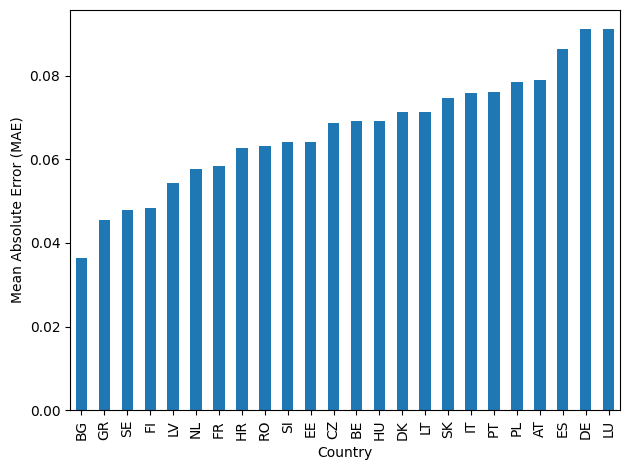

In [199]:
ax=mae_by_country.set_index('Country')['MAE'].plot(kind='bar')
ax.set_ylabel("Mean Absolute Error (MAE)")
ax.set_xlabel("Country")
plt.tight_layout()
plt.show()

**Root Mean Squared Error (RMSE) by Country**
<br> The table below presents the RMSE of the best CNN-LSTM model across all 24 EU countries, sorted in ascending order. RMSE emphasizes larger errors more than MAE, making it useful for detecting countries with occasional large prediction deviations.
- Bulgaria (BG) again ranks best with the lowest RMSE of 0.0454, indicating both consistent and accurate predictions.
- Luxembourg (LU) has the highest RMSE at 0.1281, suggesting significant variability or model difficulty in capturing its demand profile.
- Countries such as Finland (FI), Greece (GR), and Sweden (SE) also show strong performance, with RMSEs below 0.065.
- Higher RMSEs in Spain (ES), Germany (DE), and Luxembourg (LU) may indicate the need for region-specific tuning or additional feature enrichment (add data centers consumption for example)

In [200]:
# Root Mean Squared Error by Country
rmse_by_country=results_df.groupby("CountryCode")['sq_error'].mean().apply(np.sqrt).sort_values().reset_index()
rmse_by_country.columns = ["CountryCode", "RMSE"]
rmse_by_country=rmse_by_country.merge(country_map,on='CountryCode',how='left').drop(columns='CountryCode')

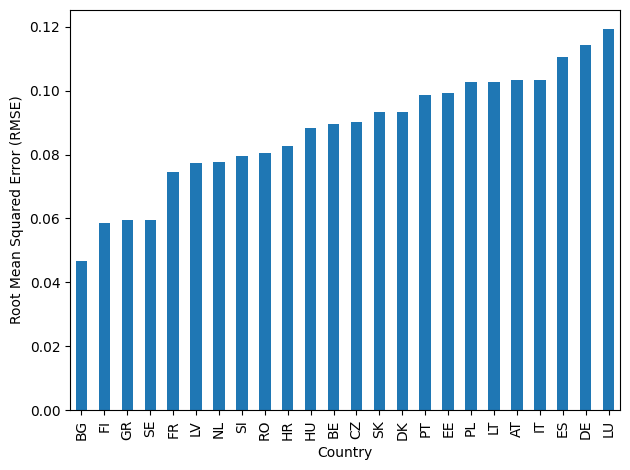

In [201]:
ax=rmse_by_country.set_index('Country')['RMSE'].plot(kind='bar')
ax.set_ylabel("Root Mean Squared Error (RMSE)")
ax.set_xlabel("Country")
plt.tight_layout()
plt.show()

In [202]:
results_df=results_df.merge(country_map,on='CountryCode',how='left').drop(columns='CountryCode')

The boxplot provides a country-wise breakdown of prediction errors for the CNN-LSTM model, using absolute error per time step as the evaluation metric. The countries are represented by their two-letter ISO codes, and the model's accuracy and consistency are inferred from the distribution of errors.

**Countries with Low Errors and High Consistency:**
<br> These countries show low median absolute errors and tight interquartile ranges (IQR)—indicating stable and accurate predictions.
- BG (Bulgaria), FI (Finland), GR (Greece), SE (Sweden):
- Exhibit the lowest medians and few outliers, suggesting the model performs best in these regions.
- Likely due to more regular or predictable consumption patterns.

**Countries with Moderate Errors:**
<br> These countries have slightly wider IQRs and moderate error levels:
- FR (France), HR (Croatia), HU (Hungary), RO (Romania), SI (Slovenia), CZ (Czech Republic), NL (Netherlands), LT (Lithuania):
- The model performs fairly well but shows slightly more variability.

**Countries with High Errors and Outliers:**
<br> These countries show higher medians, wider IQRs, and many extreme outliers, indicating inconsistent predictions:
- DE (Germany), LU (Luxembourg), PL (Poland), IT (Italy), PT (Portugal):
- High absolute error variability may be due to:
    - Irregular consumption behaviors,
    - Anomalies or noise in the data,
    - Structural patterns not well captured by the model (e.g., holidays, local peaks).

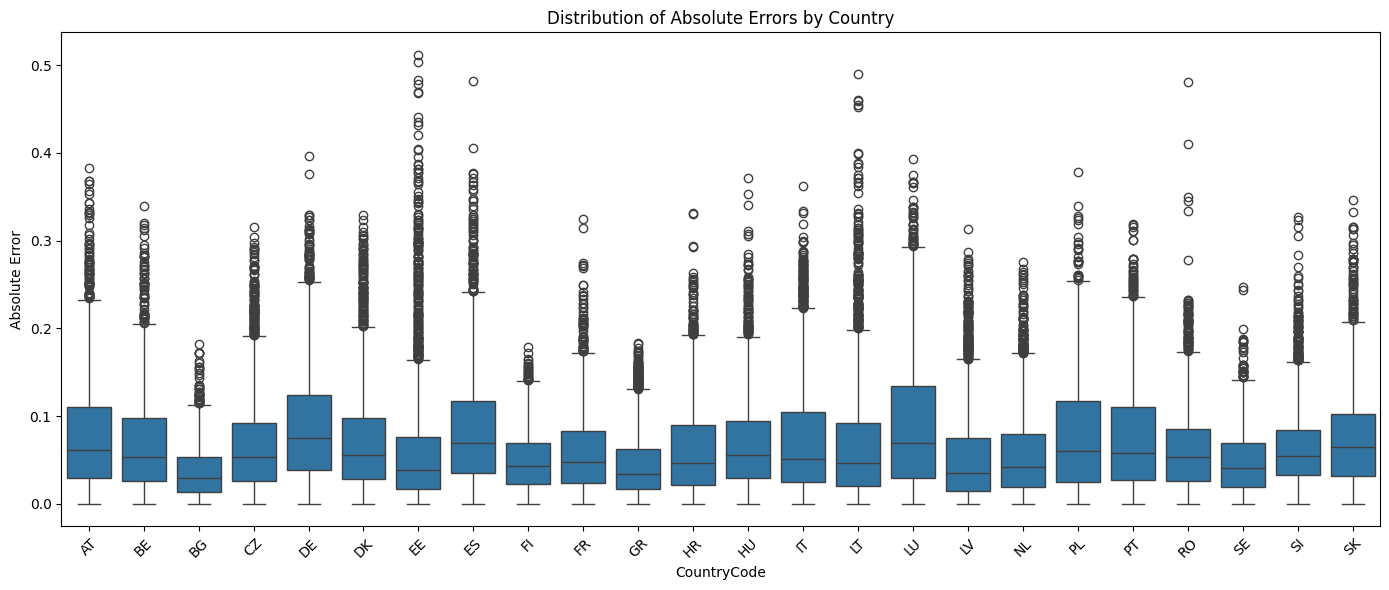

In [203]:
plt.figure(figsize=(14,6))
sns.boxplot(data=results_df, x='Country', y='abs_error')
plt.title("Distribution of Absolute Errors by Country")
plt.ylabel("Absolute Error")
plt.xlabel("CountryCode")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Display the 5 predictions with the highest and lowest absolute errors


In [204]:
worst_examples = results_df.sort_values('abs_error', ascending=False).head(5)
best_examples = results_df.sort_values('abs_error').head(5)

print("Worst Prediction Examples:")
display(worst_examples)
print("\nBest Prediction Examples:")
display(best_examples)

Worst Prediction Examples:


,y_true,y_pred,abs_error,sq_error,Country
14889,0.034225,0.546150,0.511925,0.262067,EE
14890,0.001801,0.505086,0.503285,0.253295,EE
31163,0.164107,0.654500,0.490392,0.240485,LT
14888,0.069441,0.552779,0.483339,0.233616,EE
15796,-0.155931,0.325781,0.481712,0.232046,ES



Best Prediction Examples:


,y_true,y_pred,abs_error,sq_error,Country
19155,0.409783,0.409783,2.682209e-07,7.194245e-14,FI
8874,0.833986,0.833984,2.324581e-06,5.403678e-12,DE
20702,0.481797,0.481794,2.890825e-06,8.356871e-12,FR
44065,0.629801,0.629797,3.933907e-06,1.547562e-11,RO
30718,0.366222,0.366228,6.020069e-06,3.624123e-11,LT
